In [1]:
# Import Libs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

In [28]:
# Load dataset
df = pd.read_csv("Iris.csv")

In [29]:
# Remove Id column and run the head function
df = df.drop(columns="Id")
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Basic Info
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [6]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
# Check for null values
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

<Axes: >

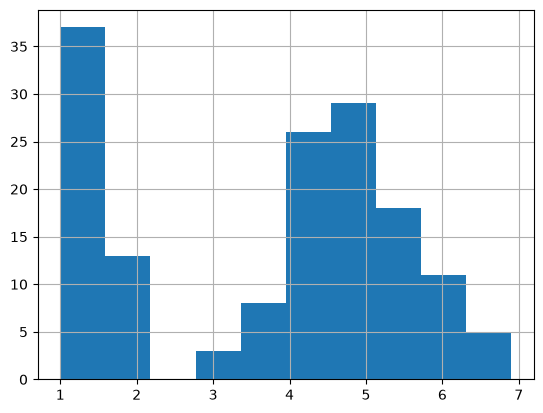

In [8]:
# Histograms for all features
df["PetalLengthCm"].hist()

<Axes: >

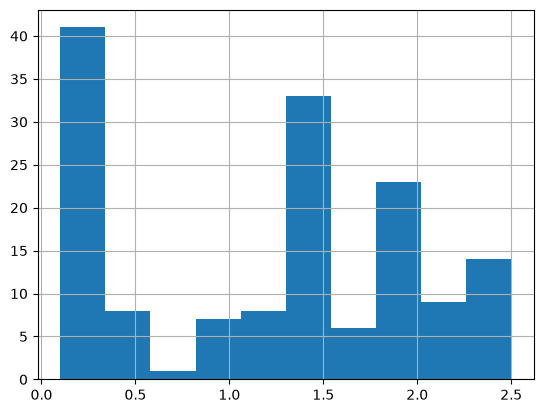

In [9]:
df["PetalWidthCm"].hist()

<Axes: >

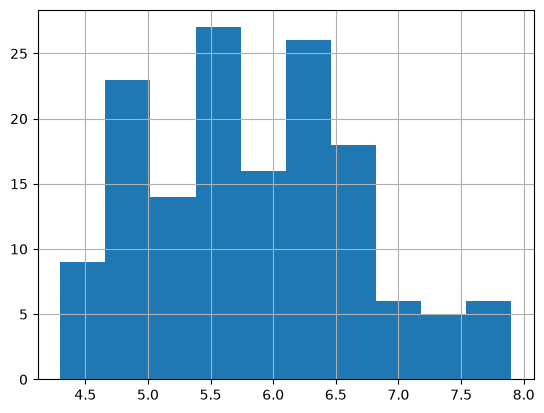

In [10]:
df["SepalLengthCm"].hist()

<Axes: >

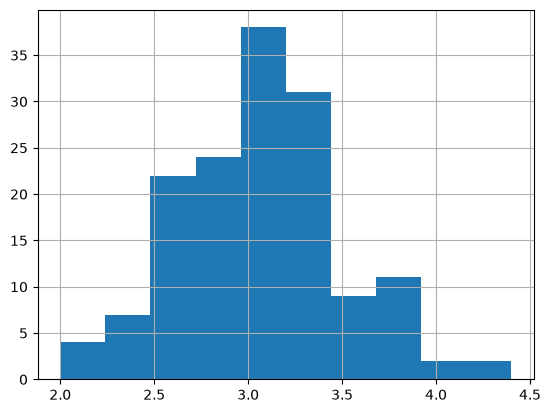

In [11]:
df["SepalWidthCm"].hist()

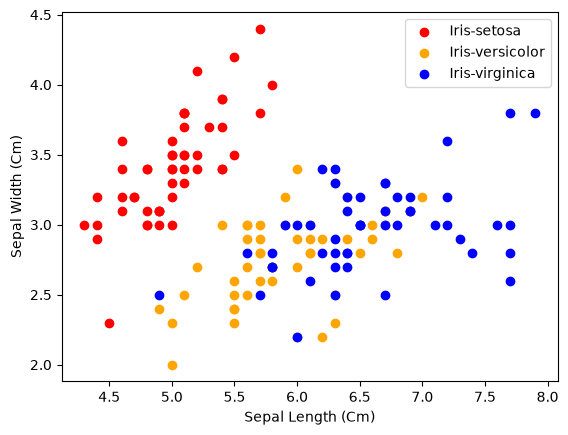

In [12]:
# Scatter plot for SepalLength - SepalWidth
colors = ["red", "orange", "blue"]
species = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

for i in range(3):
    x = df[df["Species"] == species[i]]
    plt.scatter(x["SepalLengthCm"], x["SepalWidthCm"], c=colors[i], label=species[i])
plt.xlabel("Sepal Length (Cm)")
plt.ylabel("Sepal Width (Cm)")
plt.legend()

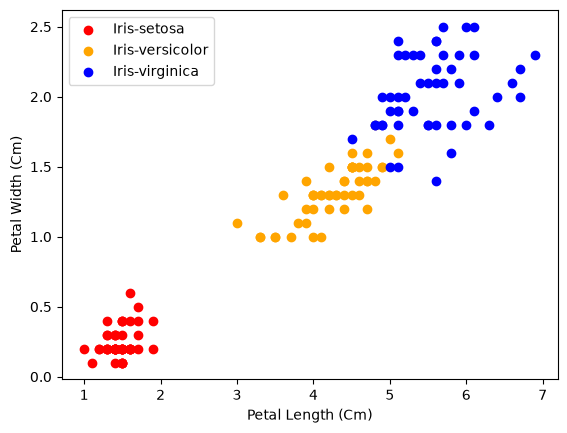

In [13]:
# Scatter plot for PetalLength - PetalWidth
colors = ["red", "orange", "blue"]
species = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

for i in range(3):
    x = df[df["Species"] == species[i]]
    plt.scatter(x["PetalLengthCm"], x["PetalWidthCm"], c=colors[i], label=species[i])
plt.xlabel("Petal Length (Cm)")
plt.ylabel("Petal Width (Cm)")
plt.legend()

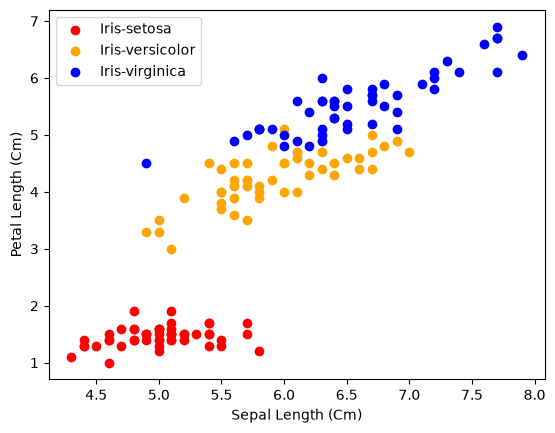

In [14]:
# Scatter plot for SepalLength - PetalLength
colors = ["red", "orange", "blue"]
species = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

for i in range(3):
    x = df[df["Species"] == species[i]]
    plt.scatter(x["SepalLengthCm"], x["PetalLengthCm"], c=colors[i], label=species[i])
plt.xlabel("Sepal Length (Cm)")
plt.ylabel("Petal Length (Cm)")
plt.legend()

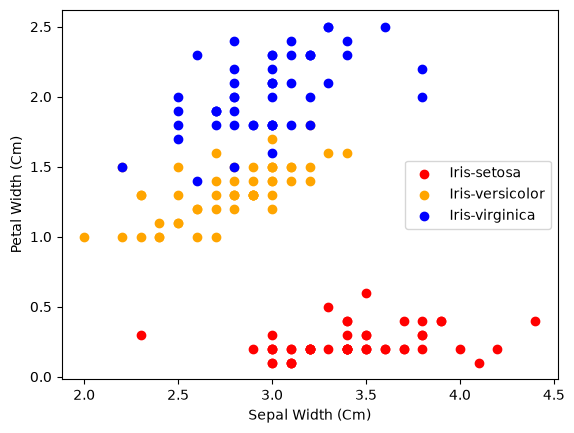

In [15]:
# Scatter plot for SepalWidth - PetalWidth
colors = ["red", "orange", "blue"]
species = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

for i in range(3):
    x = df[df["Species"] == species[i]]
    plt.scatter(x["SepalWidthCm"], x["PetalWidthCm"], c=colors[i], label=species[i])
plt.xlabel("Sepal Width (Cm)")
plt.ylabel("Petal Width (Cm)")
plt.legend()

In [16]:
# Correlation matrix
df.corr(numeric_only=True)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


<Axes: >

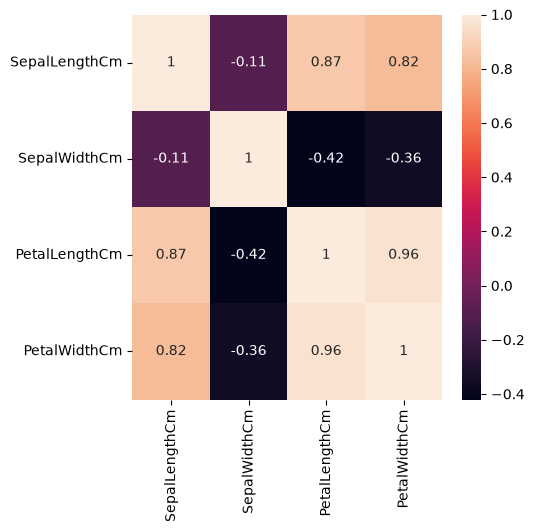

In [17]:
# Correlation matrix heatmap
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize = (5,5))
sns.heatmap(corr, annot=True, ax=ax)

In [18]:
# Import label encoder library
from sklearn.preprocessing import LabelEncoder

In [19]:
# Encode the Species column
le = LabelEncoder()
df["Species"] = le.fit_transform(df["Species"])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [30]:
# Split into train and test sets (70/30)
from sklearn.model_selection import train_test_split
X = df.drop(columns=["Species"])
Y = df["Species"]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.30)

In [21]:
# Train with Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(x_train, y_train)
print("Accuracy: ", model.score(x_test,y_test)*100)

Accuracy:  91.11111111111111


In [22]:
# Train with Knn
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()

model.fit(x_train,y_train)
print("Accuracy: ", model.score(x_test,y_test)*100)

Accuracy:  93.33333333333333


In [31]:
# Train with desicion trees
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

model.fit(x_train,y_train)
print("Accuracy: ", model.score(x_test,y_test)*100)

Accuracy:  100.0


In [32]:
# Save the desicion tree model
import pickle

filename = "savedmodel.sav"
pickle.dump(model, open(filename, "wb"))

In [33]:
# Load the model
load_model = pickle.load(open(filename, "rb"))

In [35]:
# Sample prediction (Trained without label encoder)
load_model.predict([[3.1, 2.1, 1.0, 4.5]])

C:\Users\ktran\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['Iris-setosa'], dtype=object)